In [36]:
%matplotlib inline
import os, sys, pickle
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import functools
import matplotlib.pyplot as plt
torch.load = functools.partial(torch.load, map_location=torch.device("cpu"))  # log.pkl was saved on CUDA; force CPU load on this machine
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from scipy import stats
import os as _os, sys as _sys
_ROOT = _os.path.dirname(_os.path.abspath(""))
_sys.path.insert(0, _ROOT)
_sys.path.insert(0, _os.path.dirname(_ROOT))

from mcpilco.config_single_phase import get_config
from mcpilco.pensim_wrapper import ( WARMUP_H, K_WARM,
    PenSimWrapper, PenSimMCPILCO, STATE_NAMES, STATE_RANGES, STATE_DIM,
    T_SAMPLING, CONTROL_H, PAA_BAND, VISC_MAX, FPAA_MIN, FPAA_MAX,
    FS_SCALE, initial_state_norm, decode_state_value,
)
from utils.recipe import Recipe
from utils.constants import STEP_IN_HOURS
from PenSimPy.pensimpy.data.constants import (
    FS, FS_DEFAULT_PROFILE, DISCHARGE, DISCHARGE_DEFAULT_PROFILE,
)
from experiments.eval_utils import yield_kg, constraint_diagnostics

P_IDX = STATE_NAMES.index("P")
X_IDX = STATE_NAMES.index("X")
ACTION_IDX = STATE_DIM


In [ ]:
SEED             = 5
RUN_SUFFIX       = 6
NUM_TRIALS       = 10
FAST             = False
GP_TRIAL         = None
OPTIM_HORIZON    = None
NUM_ANCHORS      = None
NUM_EXPLORATIONS = 5

N_EVAL_SEEDS = 10
EVAL_BASE    = 700000
COMPARE_SEED = EVAL_BASE

RECIPE_DIR   = os.path.join(_ROOT, "results/batch_recipe_generation")
RECIPE_BATCH = 5

RESULTS_DIR = os.path.join(_ROOT, f"results/single_phase_baseline/seed{SEED}_{RUN_SUFFIX}")
RUN_DIR = Path(RESULTS_DIR)
assert (RUN_DIR / "log.pkl").exists(), f"no log.pkl under {RUN_DIR}"
print("run dir:", RUN_DIR)


run dir: /Users/rokaspranevicius/Documents/Aca/UniversityOfEdinburgh/MSc/pensimpy_mcpilco/pensim_mcpilco/results/single_phase_baseline/seed5_5


## R.1 - Policy optimisation: imagined cost per optimisation step

For each trial, `cost_trial_list[j]` holds the imagined cost J at every Adam step of that
trial's policy optimisation. Three things make this data easy to misread:

- **Index offset.** `cost_trial_list[j]` corresponds to `state_samples_history[n_expl + j]`,
  not `[j]` -- the exploration episodes come first in the episode histories.
- **Not comparable across trials.** The GP is re-fit every trial, so J is an expectation
  under a *different model* each time. Only the within-trial shape carries meaning; the
  curves are therefore drawn as small multiples with independent y-scales, never overlaid.
- **Variable length.** Optimisation exits early on the `min_diff_cost` criterion and the
  counter resets on NaN re-init, so curves are trimmed at their last filled step rather
  than padded to a common length.

R.2 then tests the part that actually matters: whether a lower imagined J predicts a higher
real batch yield.

In [38]:
log = pickle.load(open(RUN_DIR / "log.pkl", "rb"))
_mon_path = RUN_DIR / "monitor.pkl"
monitors = pickle.load(open(_mon_path, "rb")) if _mon_path.exists() else None

def _trim(v):
    """Drop the unfilled tail. Costs are O(100) in magnitude, so an exact 0 means
    'never written' -- either early exit or a NaN re-init that re-zeroed the buffer."""
    v = np.asarray(v, dtype=float)
    nz = np.nonzero(v)[0]
    return v[: nz[-1] + 1] if len(nz) else v[:0]


cost_curves = [_trim(c) for c in log["cost_trial_list"]]
std_curves = [_trim(s) for s in log["std_cost_trial_list"]]
n_trials = len(cost_curves)

# Derive the exploration count from the data rather than trusting NUM_EXPLORATIONS: a run
# whose config was edited mid-experiment would otherwise be silently mis-aligned here.
state_hist = log["state_samples_history"]
n_expl = len(state_hist) - n_trials
assert n_expl >= 0, f"{n_trials} trials but only {len(state_hist)} episodes"
if n_expl != NUM_EXPLORATIONS:
    print(f"WARNING: derived n_expl={n_expl} != NUM_EXPLORATIONS={NUM_EXPLORATIONS}; using {n_expl}")

# Yield of the batch each trial's policy was then executed on. TAIL_N averages the last few
# optimisation steps: a single final value is one noisy particle draw, not a stable estimate.
TAIL_N = 20
rows = []
for j, c in enumerate(cost_curves):
    ep = n_expl + j
    rows.append({
        "trial": j,
        "episode": ep,
        "opt_steps": len(c),
        "J_first": c[0],
        "J_final": c[-1],
        "J_tail": c[-TAIL_N:].mean(),
        "J_min": c.min(),
        "argmin": int(c.argmin()),
        "real_yield_kg": yield_kg(monitors[ep]) if monitors else np.nan,
    })
opt_df = pd.DataFrame(rows)

expl_yields = [yield_kg(monitors[i]) for i in range(n_expl)] if monitors else []
print(f"{n_expl} exploration episodes + {n_trials} policy episodes = {len(state_hist)} total")
if expl_yields:
    print(f"exploration yield: mean {np.mean(expl_yields):.0f} kg, "
          f"range [{min(expl_yields):.0f}, {max(expl_yields):.0f}]")
opt_df.round(2)

5 exploration episodes + 10 policy episodes = 15 total
exploration yield: mean 3268 kg, range [2683, 3805]


,trial,episode,opt_steps,J_first,J_final,J_tail,J_min,argmin,real_yield_kg
0,0,5,702,-149.05,-182.66,-181.81,-184.40,635,522.46
1,1,6,553,-146.36,-189.78,-187.35,-190.88,423,3988.65
2,2,7,539,-184.62,-197.20,-196.57,-200.34,451,3992.22
3,3,8,539,-182.69,-197.55,-197.96,-202.42,443,3341.10
4,4,9,539,-190.84,-190.67,-191.77,-197.43,427,4263.28
5,5,10,539,-191.28,-194.83,-191.45,-195.26,36,3692.40
6,6,11,539,-186.82,-189.05,-187.45,-191.56,372,3683.38
7,7,12,539,-193.50,-195.30,-194.46,-199.40,471,4291.93
8,8,13,539,-195.58,-199.59,-199.49,-204.53,495,4404.12
9,9,14,539,-188.67,-189.83,-190.99,-195.27,408,3710.79


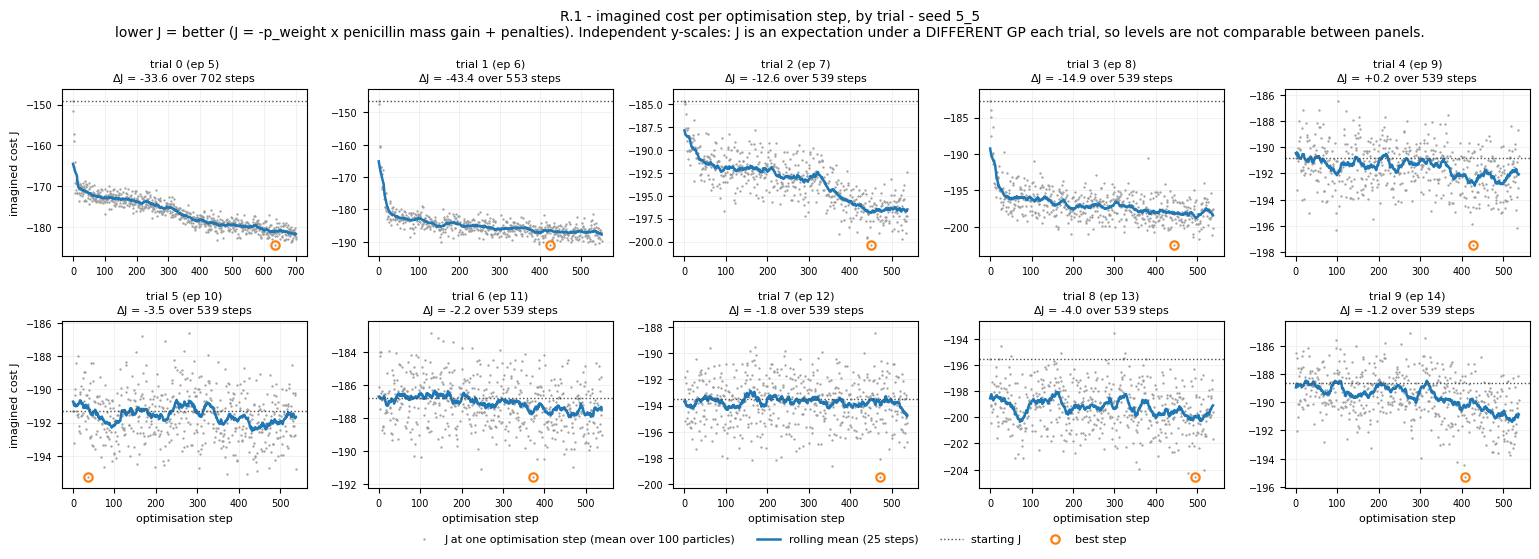

trials ending WORSE than they started: 1/10  -> [4]
minimum reached in the final 25% of steps: 8/10 (low count => the last iterate is not near the best iterate)


In [39]:
def _roll(v, w=25):
    """Centred rolling mean, for reading the trend through per-step sampling noise."""
    if len(v) < w:
        return v
    k = np.ones(w) / w
    return np.convolve(v, k, mode="same") / np.convolve(np.ones_like(v), k, mode="same")


_ncol = min(5, n_trials)
_nrow = int(np.ceil(n_trials / _ncol))
fig, ax = plt.subplots(_nrow, _ncol, figsize=(3.1 * _ncol, 2.7 * _nrow), squeeze=False)

for j, c in enumerate(cost_curves):
    a = ax[j // _ncol, j % _ncol]
    steps = np.arange(len(c))
    # Dots, not a line: 700+ noisy samples joined up read as a shaded band, which invites
    # mistaking the raw trace for a variance envelope. Each dot is ONE Adam step, and is itself
    # already a mean over 100 particles. Its scatter is the sampling noise of that mean --
    # NOT the spread across particles, which is ~25x larger and lives in R.1b.
    a.plot(steps, c, ls="none", marker=".", ms=1.3, color="0.62",
           label="J at one optimisation step (mean over 100 particles)")
    a.plot(steps, _roll(c), color="C0", lw=1.8, label="rolling mean (25 steps)")
    a.axhline(c[0], color="0.3", ls=":", lw=1, label="starting J")
    a.plot(c.argmin(), c.min(), "o", ms=6, mfc="none", mec="C1", mew=1.6, label="best step")
    # y-limits from the cost curve alone.
    pad = 0.08 * (c.max() - c.min() + 1e-9)
    a.set_ylim(c.min() - pad, c.max() + pad)
    a.set_title(f"trial {j} (ep {n_expl + j})\n$\\Delta$J = {c[-1] - c[0]:+.1f} over {len(c)} steps",
                fontsize=8)
    a.grid(alpha=.25, lw=.5)
    a.tick_params(labelsize=7)
    if j % _ncol == 0:
        a.set_ylabel("imagined cost J", fontsize=8)
    if j // _ncol == _nrow - 1:
        a.set_xlabel("optimisation step", fontsize=8)

for j in range(n_trials, _nrow * _ncol):
    ax[j // _ncol, j % _ncol].axis("off")

h, l = ax[0, 0].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=4, fontsize=8, frameon=False,
           bbox_to_anchor=(0.5, -0.03))
fig.suptitle(f"R.1 - imagined cost per optimisation step, by trial - seed {SEED}_{RUN_SUFFIX}\n"
             "lower J = better (J = -p_weight x penicillin mass gain + penalties). Independent "
             "y-scales: J is an expectation under a DIFFERENT GP each trial, so levels are not "
             "comparable between panels.", fontsize=10)
fig.tight_layout()
plt.show()

_worse = opt_df[opt_df.J_final > opt_df.J_first]
print(f"trials ending WORSE than they started: {len(_worse)}/{n_trials}"
      + (f"  -> {list(_worse.trial)}" if len(_worse) else ""))
print(f"minimum reached in the final 25% of steps: "
      f"{int((opt_df.argmin > 0.75 * opt_df.opt_steps).sum())}/{n_trials} "
      "(low count => the last iterate is not near the best iterate)")

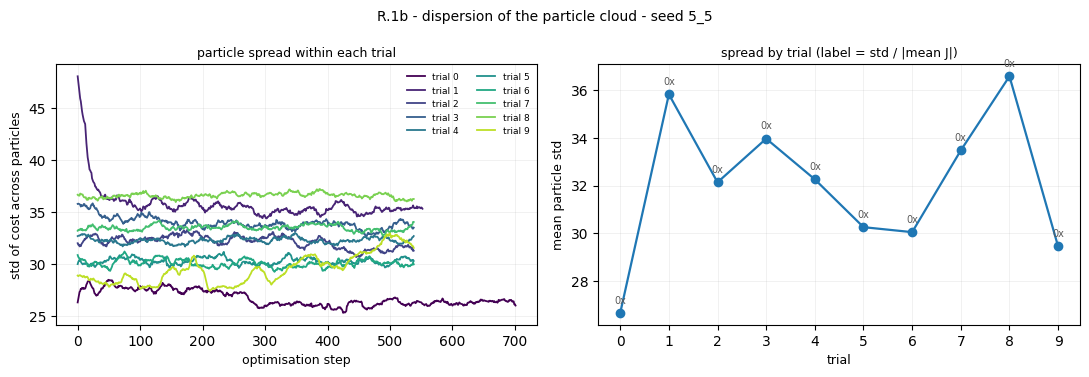

The optimiser minimises the MEAN over particles. A std this much larger than the mean means
individual imagined rollouts disagree enormously about the same policy, so each gradient step
is estimated from a very heavy-tailed sample.

mean particle std: trial 0 = 27 -> trial 9 = 29
A rising trend means the imagined rollouts are diverging MORE as training proceeds,
i.e. added data is not tightening the multi-step prediction.


In [40]:
# `std_cost_trial_list` is the spread of cost ACROSS PARTICLES, not an uncertainty on the mean
# J. It runs 20-60x larger than the whole within-trial range of J, so it gets its own axis --
# overlaying it on R.1 would flatten every cost curve to a horizontal line.
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))

_cmap = cm.viridis(np.linspace(0, .9, n_trials))
for j, s in enumerate(std_curves):
    ax[0].plot(np.arange(len(s)), _roll(s), color=_cmap[j], lw=1.3, label=f"trial {j}")
ax[0].set_xlabel("optimisation step", fontsize=9)
ax[0].set_ylabel("std of cost across particles", fontsize=9)
ax[0].set_title("particle spread within each trial", fontsize=9)
ax[0].grid(alpha=.25, lw=.5)
ax[0].legend(fontsize=6.5, ncol=2, frameon=False)

_ratio = [s.mean() / abs(c.mean()) for c, s in zip(cost_curves, std_curves)]
ax[1].plot(range(n_trials), [s.mean() for s in std_curves], "o-", color="C0", lw=1.6, ms=6)
for j, v in enumerate([s.mean() for s in std_curves]):
    ax[1].annotate(f"{_ratio[j]:.0f}x", (j, v), fontsize=7, xytext=(0, 7),
                   textcoords="offset points", ha="center", color="0.35")
ax[1].set_xlabel("trial", fontsize=9)
ax[1].set_ylabel("mean particle std", fontsize=9)
ax[1].set_title("spread by trial (label = std / |mean J|)", fontsize=9)
ax[1].set_xticks(range(n_trials))
ax[1].grid(alpha=.25, lw=.5)

fig.suptitle(f"R.1b - dispersion of the particle cloud - seed {SEED}_{RUN_SUFFIX}", fontsize=10)
fig.tight_layout()
plt.show()

print("The optimiser minimises the MEAN over particles. A std this much larger than the mean means")
print("individual imagined rollouts disagree enormously about the same policy, so each gradient step")
print("is estimated from a very heavy-tailed sample.")
print(f"\nmean particle std: trial 0 = {std_curves[0].mean():.0f} -> "
      f"trial {n_trials-1} = {std_curves[-1].mean():.0f}")
print("A rising trend means the imagined rollouts are diverging MORE as training proceeds,")
print("i.e. added data is not tightening the multi-step prediction.")

## R.2 - Does the imagined cost predict the real batch?

R.1 only shows whether Adam descended its own objective. That objective is an expectation
under the GP, and the GP is the component known to hallucinate off-distribution -- so a
falling J is not evidence the policy improved on the reactor.

This cell tests the link directly: each trial's converged imagined cost against the real
yield of the batch that policy then produced. A strong negative correlation (lower J ->
higher yield) means the optimisation target is meaningful. A flat or positive relationship
means every curve in R.1 is progress against a fiction, and nothing downstream of the
imagined cost -- including checkpoint selection -- can be trusted.

Note the sample size is one point per trial. With ~10 trials this is suggestive, not
conclusive; Spearman is reported alongside Pearson because the relationship need not be
linear and a single collapsed batch would dominate a Pearson fit.

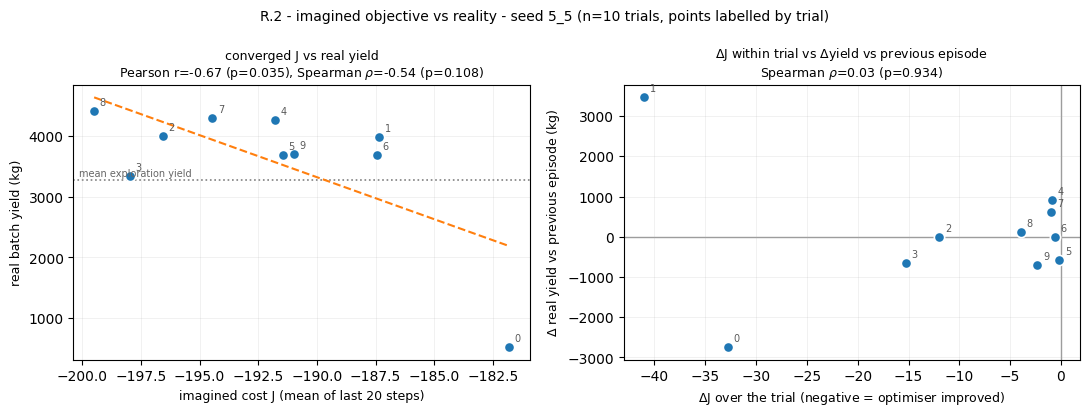

real yield over policy episodes: mean 3589 kg, range [522, 4404]
vs exploration mean 3268 kg

negative Pearson/Spearman on the LEFT  => lower imagined cost really does mean a better batch
negative Spearman on the RIGHT        => a trial that optimised well really did improve the batch
flat or positive on either            => the imagined objective is not tracking the reactor


In [41]:
if monitors is None:
    print("no monitor.pkl in the run dir -> real yields unavailable, skipping R.2")
else:
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

    # --- left: converged imagined J vs the real yield it produced -------------------
    x, y = opt_df.J_tail.values, opt_df.real_yield_kg.values
    a = ax[0]
    a.scatter(x, y, s=55, color="C0", zorder=3, edgecolor="white", linewidth=1.2)
    for _, r in opt_df.iterrows():
        a.annotate(int(r.trial), (r.J_tail, r.real_yield_kg), fontsize=7,
                   xytext=(4, 4), textcoords="offset points", color="0.35")
    if len(x) > 2:
        pr, pp = stats.pearsonr(x, y)
        sr, sp = stats.spearmanr(x, y)
        b1, b0 = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 50)
        a.plot(xs, b0 + b1 * xs, "C1--", lw=1.5, zorder=2)
        a.set_title(f"converged J vs real yield\nPearson r={pr:.2f} (p={pp:.3f}), "
                    f"Spearman $\\rho$={sr:.2f} (p={sp:.3f})", fontsize=9)
    if expl_yields:
        a.axhline(np.mean(expl_yields), color="0.5", ls=":", lw=1.2, zorder=1)
        a.annotate("mean exploration yield", (a.get_xlim()[0], np.mean(expl_yields)),
                   fontsize=7, xytext=(4, 3), textcoords="offset points", color="0.4")
    a.set_xlabel(f"imagined cost J (mean of last {TAIL_N} steps)", fontsize=9)
    a.set_ylabel("real batch yield (kg)", fontsize=9)
    a.grid(alpha=.25, lw=.5)

    # --- right: within-trial J improvement vs the real yield change it delivered ----
    # Both axes are differences, so this asks the sharper question: when optimisation
    # reports progress, does the reactor agree?
    dJ = (opt_df.J_tail - opt_df.J_first).values
    dY = np.diff(np.concatenate([[np.mean(expl_yields)], opt_df.real_yield_kg.values]))
    a = ax[1]
    a.scatter(dJ, dY, s=55, color="C0", zorder=3, edgecolor="white", linewidth=1.2)
    for j, (xi, yi) in enumerate(zip(dJ, dY)):
        a.annotate(j, (xi, yi), fontsize=7, xytext=(4, 4),
                   textcoords="offset points", color="0.35")
    a.axhline(0, color="0.6", lw=1, zorder=1)
    a.axvline(0, color="0.6", lw=1, zorder=1)
    if len(dJ) > 2:
        sr2, sp2 = stats.spearmanr(dJ, dY)
        a.set_title(f"$\\Delta$J within trial vs $\\Delta$yield vs previous episode\n"
                    f"Spearman $\\rho$={sr2:.2f} (p={sp2:.3f})", fontsize=9)
    a.set_xlabel("$\\Delta$J over the trial (negative = optimiser improved)", fontsize=9)
    a.set_ylabel("$\\Delta$ real yield vs previous episode (kg)", fontsize=9)
    a.grid(alpha=.25, lw=.5)

    fig.suptitle(f"R.2 - imagined objective vs reality - seed {SEED}_{RUN_SUFFIX} "
                 f"(n={n_trials} trials, points labelled by trial)", fontsize=10)
    fig.tight_layout()
    plt.show()

    print(f"real yield over policy episodes: mean {opt_df.real_yield_kg.mean():.0f} kg, "
          f"range [{opt_df.real_yield_kg.min():.0f}, {opt_df.real_yield_kg.max():.0f}]")
    if expl_yields:
        print(f"vs exploration mean {np.mean(expl_yields):.0f} kg")
    print("\nnegative Pearson/Spearman on the LEFT  => lower imagined cost really does mean a better batch")
    print("negative Spearman on the RIGHT        => a trial that optimised well really did improve the batch")
    print("flat or positive on either            => the imagined objective is not tracking the reactor")

## R.3 - GP predictive variance along each episode

R.1 shows the imagined cost falling; R.1b shows the particle cloud is heavy-tailed. Neither
tells you where in the episode the GP itself was uncertain. This section reloads the *actual*
GP each trial optimised its policy against (trial `j` used the GP fit on episodes
`0 .. n_expl+j-1`, i.e. `parameters_gp_{n_expl-1+j}`) and evaluates its one-step predictive
std **teacher-forced along the real trajectory that trial's policy then produced** (episode
`n_expl+j`).

Teacher-forced means the true state is fed back at every step, so this isolates the GP's own
uncertainty about the states actually visited -- it does not compound like the multi-step
particle rollout in R.1b. `time` is excluded: its rollout update is forced deterministic
(`model_learning_det_time.py`), so its GP variance is not physically meaningful here. All
other channels are already normalised to `[-1, 1]`, so std is directly comparable across
channels on one axis.

In [42]:
import contextlib, io


def _reconstruct_gp(seed, num_trials, fast, log, idx):
    """Build a PenSimMCPILCO and load the trial-`idx` GP model from `log` (no training)."""
    with contextlib.redirect_stdout(io.StringIO()):
        cfg = get_config(seed=seed, num_trials=num_trials, fast=fast)
        cfg["mc_pilco_init"]["log_path"] = None
        agent = PenSimMCPILCO(pensim_wrapper=PenSimWrapper(**cfg["wrapper_par"]),
                              **cfg["mc_pilco_init"])
    agent.state_samples_history = log["state_samples_history"]
    agent.input_samples_history = log["input_samples_history"]
    agent.noiseless_states_history = log.get("noiseless_states_history",
                                             log["state_samples_history"])
    ml = agent.model_learning
    ml.gp_inputs = log[f"gp_inputs_{idx}"]
    ml.gp_output_list = log[f"gp_output_list_{idx}"]
    ml.num_samples = ml.gp_inputs.shape[0]
    ml.dim_state = len(STATE_NAMES)
    ml.init_gp_models()
    params = log[f"parameters_gp_{idx}"]
    for k in range(ml.num_gp):
        ml.gp_list[k].load_state_dict(params[k])
        # mirrors flg_norm at train time: config_single_phase leaves it at the Model_learning
        # default (False), so norm stays 1 and var below is already in raw normalised-delta^2
        # units -- rescaling here would silently corrupt the std comparison across trials.
        ml.norm_list[k] = (torch.max(torch.abs(ml.gp_output_list[k]))
                           if getattr(ml, "flg_norm", False)
                           else torch.tensor(1.0, dtype=agent.dtype))
    with torch.no_grad(), contextlib.redirect_stdout(io.StringIO()):
        for k in range(ml.num_gp):
            ml.pretrain_gp(k)
    ml.set_eval_mode()
    return agent


CHANNELS_TO_PLOT = [n for n in STATE_NAMES if n != "time"]
_chan_idx = [STATE_NAMES.index(n) for n in CHANNELS_TO_PLOT]
_chan_color = dict(zip(CHANNELS_TO_PLOT, cm.tab10(np.linspace(0, 1, len(CHANNELS_TO_PLOT)))))

var_curves = []  # var_curves[j] = {channel: predictive std array over the episode's steps}
for j in range(n_trials):
    idx_model = n_expl - 1 + j
    ep = n_expl + j
    gp_agent = _reconstruct_gp(SEED, NUM_TRIALS, FAST, log, idx_model)
    with torch.no_grad(), contextlib.redirect_stdout(io.StringIO()):
        _, _, _, gp_var_list = gp_agent.get_model_learning_performance(ep)
    var_curves.append({
        name: np.sqrt(gp_var_list[k].detach().cpu().numpy().ravel())
        for name, k in zip(CHANNELS_TO_PLOT, _chan_idx)
    })

fig, ax = plt.subplots(_nrow, _ncol, figsize=(3.1 * _ncol, 2.7 * _nrow), squeeze=False)
for j, vc in enumerate(var_curves):
    a = ax[j // _ncol, j % _ncol]
    for name in CHANNELS_TO_PLOT:
        a.plot(np.arange(len(vc[name])), vc[name], color=_chan_color[name], lw=1.3, label=name)
    a.set_title(f"trial {j} (ep {n_expl + j})\nGP model idx {n_expl - 1 + j}", fontsize=8)
    a.grid(alpha=.25, lw=.5)
    a.tick_params(labelsize=7)
    if j % _ncol == 0:
        a.set_ylabel("GP one-step\npredicted std", fontsize=8)
    if j // _ncol == _nrow - 1:
        a.set_xlabel("step within episode", fontsize=8)

for j in range(n_trials, _nrow * _ncol):
    ax[j // _ncol, j % _ncol].axis("off")

h, l = ax[0, 0].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=len(CHANNELS_TO_PLOT), fontsize=8, frameon=False,
           bbox_to_anchor=(0.5, -0.03))
fig.suptitle(f"R.3 - GP one-step predictive std along the REAL episode each trial produced - "
             f"seed {SEED}_{RUN_SUFFIX}\nteacher-forced (true state fed at every step) -- this is "
             "the GP's own uncertainty on the trajectory actually taken, not compounding rollout "
             "error", fontsize=10)
fig.tight_layout()
plt.show()

_peak = {name: max(vc[name].max() for vc in var_curves) for name in CHANNELS_TO_PLOT}
print("peak one-step predicted std per channel across all trials (normalised units):")
for name, v in sorted(_peak.items(), key=lambda kv: -kv[1]):
    print(f"  {name:>10}: {v:.4f}")

RuntimeError: Error(s) in loading state_dict for RBF_WtMassBalance:
	size mismatch for log_lengthscales_par: copying a param with shape torch.Size([5]) from checkpoint, the shape in current model is torch.Size([6]).